In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_train = pd.read_csv("fraudTrain.csv")

print("Training Shape:", df_train.shape)
print("\nColumns:")
print(df_train.columns.tolist())

display(df_train.head())

Training Shape: (155359, 23)

Columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


In [4]:
df_test = pd.read_csv("fraudTest.csv")

print("Testing Shape:", df_test.shape)
display(df_test.head())

Testing Shape: (159180, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1.371817e+09,33.986391,-81.200714,0.0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1.371817e+09,39.450498,-109.960431,0.0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1.371817e+09,40.495810,-74.196111,0.0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1.371817e+09,28.812398,-80.883061,0.0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1.371817e+09,44.959148,-85.884734,0.0


In [5]:
print("Training missing values:")
print(df_train.isnull().sum())

print("\nTraining duplicate rows:", df_train.duplicated().sum())

print("\nFraud distribution:")
print(df_train['is_fraud'].value_counts())

Training missing values:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      1
trans_num                1
unix_time                1
merch_lat                1
merch_long               1
is_fraud                 1
dtype: int64

Training duplicate rows: 0

Fraud distribution:
is_fraud
0.0    153928
1.0      1430
Name: count, dtype: int64


Fraud Distribution:
is_fraud
0.0    153928
1.0      1430
Name: count, dtype: int64

Fraud Percentage:
is_fraud
0.0    99.079545
1.0     0.920455
Name: proportion, dtype: float64


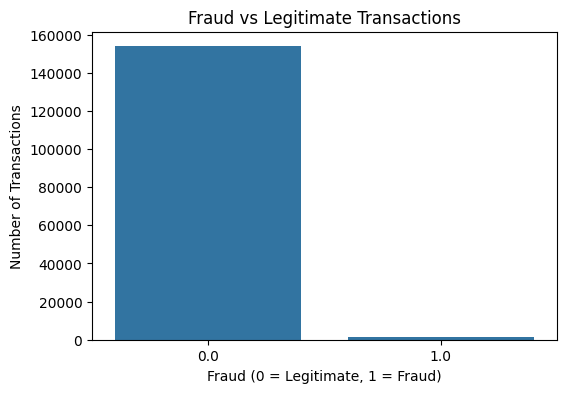

In [6]:
print("Fraud Distribution:")
print(df_train['is_fraud'].value_counts())

print("\nFraud Percentage:")
print(df_train['is_fraud'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='is_fraud')

plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Fraud (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

In [8]:
def prepare_features(data):
    data = data.copy()

    # Convert date/time columns
    data['trans_date_trans_time'] = pd.to_datetime(
        data['trans_date_trans_time'],
        errors='coerce'
    )

    data['dob'] = pd.to_datetime(
        data['dob'],
        errors='coerce'
    )

    # Extract useful transaction time features
    data['trans_hour'] = data['trans_date_trans_time'].dt.hour
    data['trans_day'] = data['trans_date_trans_time'].dt.day
    data['trans_month'] = data['trans_date_trans_time'].dt.month
    data['trans_dayofweek'] = data['trans_date_trans_time'].dt.dayofweek

    # Calculate approximate customer age
    data['age'] = (
        data['trans_date_trans_time'].dt.year -
        data['dob'].dt.year
    )

    features = [
        'category',
        'amt',
        'gender',
        'state',
        'city_pop',
        'lat',
        'long',
        'merch_lat',
        'merch_long',
        'trans_hour',
        'trans_day',
        'trans_month',
        'trans_dayofweek',
        'age',
        'job'
    ]

    return data[features]


X_train = prepare_features(df_train)
X_test = prepare_features(df_test)

y_train = df_train['is_fraud']
y_test = df_test['is_fraud']

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (155359, 15)
Testing features: (159180, 15)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    'category',
    'gender',
    'state',
    'job'
]

numerical_features = [
    'amt',
    'city_pop',
    'lat',
    'long',
    'merch_lat',
    'merch_long',
    'trans_hour',
    'trans_day',
    'trans_month',
    'trans_dayofweek',
    'age'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (155359, 558)
Testing processed shape: (159180, 558)


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_features = [
    'category',
    'gender',
    'state',
    'job'
]

numerical_features = [
    'amt',
    'city_pop',
    'lat',
    'long',
    'merch_lat',
    'merch_long',
    'trans_hour',
    'trans_day',
    'trans_month',
    'trans_dayofweek',
    'age'
]

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (155359, 558)
Testing processed shape: (159180, 558)


In [13]:
print("Missing values in target:")
print(df_train['is_fraud'].isnull().sum())

print("\nTarget values:")
print(df_train['is_fraud'].value_counts(dropna=False))

print("\nTraining target shape:", y_train.shape)

Missing values in target:
1

Target values:
is_fraud
0.0    153928
1.0      1430
NaN         1
Name: count, dtype: int64

Training target shape: (155359,)


In [14]:
# Remove rows where the target label is missing
df_train = df_train.dropna(subset=['is_fraud']).copy()

# Make sure the target is integer
df_train['is_fraud'] = df_train['is_fraud'].astype(int)

print("Training shape after removing missing target:", df_train.shape)

print("\nTarget distribution:")
print(df_train['is_fraud'].value_counts())

Training shape after removing missing target: (155358, 23)

Target distribution:
is_fraud
0    153928
1      1430
Name: count, dtype: int64


In [15]:
X_train = prepare_features(df_train)

y_train = df_train['is_fraud']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Missing values in y_train:", y_train.isnull().sum())

X_train: (155358, 15)
y_train: (155358,)
Missing values in y_train: 0


In [16]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (155358, 557)
Testing processed shape: (159180, 557)


In [17]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_processed, y_train)
lr_predictions = lr_model.predict(X_test_processed)

print("✅ Logistic Regression trained")

✅ Logistic Regression trained


In [18]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train_processed, y_train)
dt_predictions = dt_model.predict(X_test_processed)

print("✅ Decision Tree trained")

✅ Decision Tree trained


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)
rf_predictions = rf_model.predict(X_test_processed)

print("✅ Random Forest trained")

✅ Random Forest trained


In [21]:
print("Missing values in test target:")
print(df_test['is_fraud'].isnull().sum())

print("\nTest target values:")
print(df_test['is_fraud'].value_counts(dropna=False))

print("\nTest target shape:", y_test.shape)

Missing values in test target:
1

Test target values:
is_fraud
0.0    158479
1.0       700
NaN         1
Name: count, dtype: int64

Test target shape: (159180,)


In [22]:
# Remove the test row with missing fraud label
df_test = df_test.dropna(subset=['is_fraud']).copy()

# Convert target to integer
df_test['is_fraud'] = df_test['is_fraud'].astype(int)

# Rebuild test features and target
X_test = prepare_features(df_test)
y_test = df_test['is_fraud']

# Transform using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Test shape after cleaning:", df_test.shape)
print("\nTest target distribution:")
print(y_test.value_counts())
print("\nMissing test labels:", y_test.isnull().sum())

Test shape after cleaning: (159179, 23)

Test target distribution:
is_fraud
0    158479
1       700
Name: count, dtype: int64

Missing test labels: 0


In [23]:
lr_predictions = lr_model.predict(X_test_processed)
dt_predictions = dt_model.predict(X_test_processed)
rf_predictions = rf_model.predict(X_test_processed)

print("✅ Predictions generated for all 3 models")

✅ Predictions generated for all 3 models


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_predictions = {
    'Logistic Regression': lr_predictions,
    'Decision Tree': dt_predictions,
    'Random Forest': rf_predictions
}

fraud_results = []

for name, predictions in model_predictions.items():
    fraud_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1-Score': f1_score(y_test, predictions, zero_division=0)
    })

fraud_results_df = pd.DataFrame(fraud_results).round(4)

display(fraud_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9266,0.0161,0.2614,0.0304
1,Decision Tree,0.9836,0.1925,0.8529,0.3141
2,Random Forest,0.9852,0.1849,0.6929,0.2919


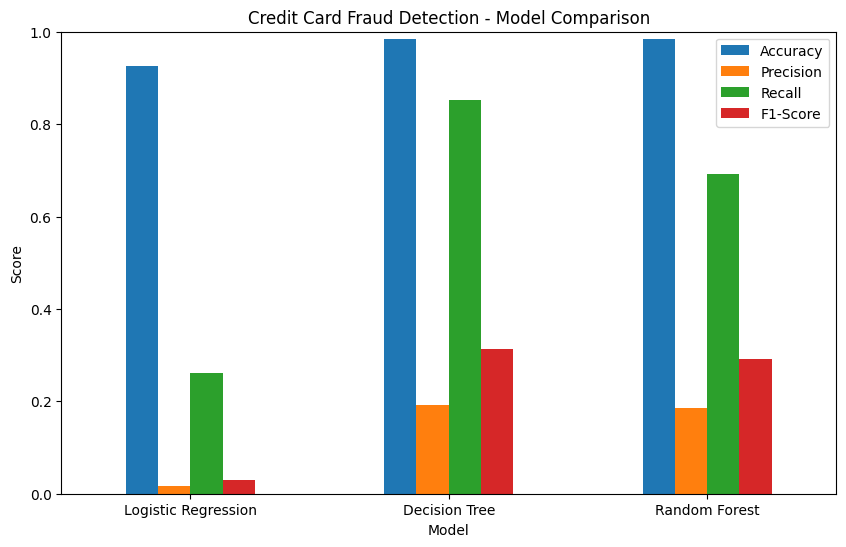

In [25]:
fraud_results_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Credit Card Fraud Detection - Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [26]:
from sklearn.metrics import classification_report

final_model = dt_model
final_predictions = dt_predictions

print("Final Model: Decision Tree")

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_predictions,
    target_names=['Legitimate', 'Fraud'],
    zero_division=0
))

Final Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    158479
       Fraud       0.19      0.85      0.31       700

    accuracy                           0.98    159179
   macro avg       0.60      0.92      0.65    159179
weighted avg       1.00      0.98      0.99    159179



Confusion Matrix:
[[155975   2504]
 [   103    597]]


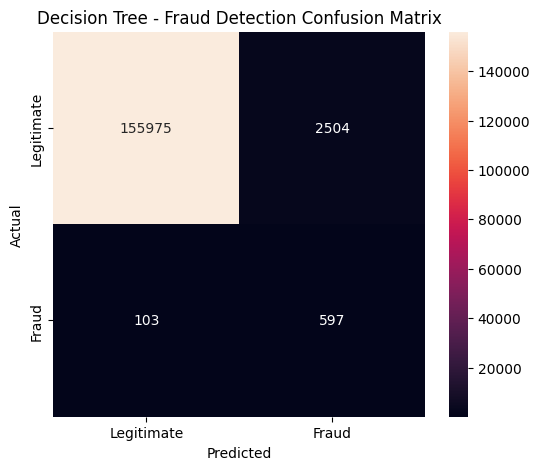

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_predictions)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)

plt.title('Decision Tree - Fraud Detection Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [28]:
sample_transaction = pd.DataFrame({
    'category': ['shopping_net'],
    'amt': [850.00],
    'gender': ['M'],
    'state': ['CA'],
    'city_pop': [50000],
    'lat': [34.05],
    'long': [-118.25],
    'merch_lat': [34.10],
    'merch_long': [-118.20],
    'trans_hour': [2],
    'trans_day': [15],
    'trans_month': [6],
    'trans_dayofweek': [5],
    'age': [35],
    'job': ['Software engineer']
})

sample_processed = preprocessor.transform(sample_transaction)

prediction = final_model.predict(sample_processed)[0]

if prediction == 1:
    print("🚨 Prediction: FRAUDULENT TRANSACTION")
else:
    print("✅ Prediction: LEGITIMATE TRANSACTION")

🚨 Prediction: FRAUDULENT TRANSACTION


In [29]:
import joblib

joblib.dump(final_model, "fraud_detection_model.pkl")
joblib.dump(preprocessor, "fraud_preprocessor.pkl")

print("✅ Fraud detection model saved")
print("✅ Preprocessor saved")

✅ Fraud detection model saved
✅ Preprocessor saved


In [30]:
import os

for file in [
    "fraud_detection_model.pkl",
    "fraud_preprocessor.pkl"
]:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

✅ fraud_detection_model.pkl
✅ fraud_preprocessor.pkl
